<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D1%81%D0%B0%D0%B9%D1%82%D0%B0/%D0%9D%D0%B5%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5_%D0%BA%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B8/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D1%83%D0%BD%D0%B8%D0%BA%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D1%85_%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BE%D1%86%D0%B5%D0%BD%D0%BA%D0%B0_%D1%81%D0%BE%D0%B3%D0%BB%D0%B0%D1%81%D0%BE%D0%B2%D0%B0%D0%BD%D0%BD%D0%BE%D1%81%D1%82%D0%B8_%D0%B2%D1%8B%D0%B1%D0%BE%D1%80%D0%BE%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Критерий Манна-Уитни: MannwhitneyuResult(statistic=np.float64(641.0), pvalue=np.float64(0.011347675538630994))
Критерий Манна-Уитни: MannwhitneyuResult(statistic=np.float64(805.5), pvalue=np.float64(4.909642963085016e-06))
Критерий Манна-Уитни: MannwhitneyuResult(statistic=np.float64(681.0), pvalue=np.float64(0.0018773499121652205))


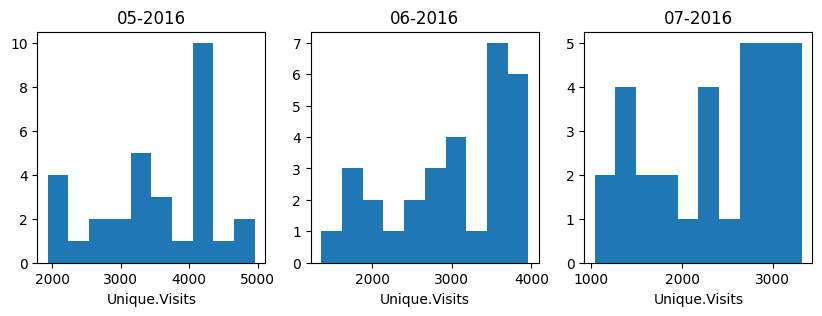

In [26]:
import scipy.stats as stats
from scipy.stats import mannwhitneyu
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("daily-website-visitors.csv")
df['Date'] = pd.to_datetime((df['Date'].str.replace("/","-")), format='%m-%d-%Y')
df['Unique.Visits']=pd.to_numeric(df['Unique.Visits'].str.replace(",",""))
df1=df[(pd.to_datetime(df['Date']).dt.year==2016) & (pd.to_datetime(df['Date']).dt.month==5)]['Unique.Visits']
df2=df[(pd.to_datetime(df['Date']).dt.year==2016) & (pd.to_datetime(df['Date']).dt.month==6)]['Unique.Visits']
df3=df[(pd.to_datetime(df['Date']).dt.year==2016) & (pd.to_datetime(df['Date']).dt.month==7)]['Unique.Visits']
# Визуализация
fig, axs = plt.subplots(1,3,figsize=(10,3))
axs[0].hist(df1)
axs[0].set_title('05-2016')
axs[0].set_xlabel('Unique.Visits')
axs[1].hist(df2)
axs[1].set_title('06-2016')
axs[1].set_xlabel('Unique.Visits')
axs[2].hist(df3)
axs[2].set_title('07-2016')
axs[2].set_xlabel('Unique.Visits')
# Применение критерия Манна-Уитни
print(f"Критерий Манна-Уитни: {mannwhitneyu(df1, df2, alternative='two-sided')}")
# p_value=0.011 < a=0.05 - гипотезу о согласованности выборок 05/2016 и 06/2016 отвергаем
print(f"Критерий Манна-Уитни: {mannwhitneyu(df1, df3, alternative='two-sided')}")
# p_value=0 < a=0.05 - гипотезу о согласованности выборок 05/2016 и 07/2016 отвергаем
print(f"Критерий Манна-Уитни: {mannwhitneyu(df2, df3, alternative='two-sided')}")
# p_value=0.001 < a=0.05 - гипотезу о согласованности выборок 06/2016 и 07/2016 отвергаем

In [30]:
from scipy.stats import *
# Применение критерия Колмогорова-Смирнова
print(f"Критерий Колмогорова-Смирнова: {kstest(df1, df2)}")
# p_value=0.0046 < a=0.05 - гипотезу о согласованности выборок 05/2016 и 06/2016 отвергаем
print(f"Критерий Колмогорова-Смирнова: {kstest(df1, df3)}")
# p_value=0 < a=0.05 - гипотезу о согласованности выборок 05/2016 и 06/2016 отвергаем
print(f"Критерий Колмогорова-Смирнова: {kstest(df2, df1)}")
# p_value=0.046 < a=0.05 - гипотезу о согласованности выборок 05/2016 и 06/2016 отвергаем

Критерий Колмогорова-Смирнова: KstestResult(statistic=np.float64(0.41935483870967744), pvalue=np.float64(0.004639987793677708), statistic_location=np.int64(3962), statistic_sign=np.int8(-1))
Критерий Колмогорова-Смирнова: KstestResult(statistic=np.float64(0.6451612903225806), pvalue=np.float64(2.184101245818353e-06), statistic_location=np.int64(3320), statistic_sign=np.int8(-1))
Критерий Колмогорова-Смирнова: KstestResult(statistic=np.float64(0.41935483870967744), pvalue=np.float64(0.004639987793677708), statistic_location=np.int64(3962), statistic_sign=np.int8(1))
